In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("06-study_hours_grades.csv")

In [3]:
df.describe()

,study_hours,grade
count,50.000000,50.000000
mean,4.459239,32.290305
std,2.888832,14.431931
min,0.205845,11.032281
25%,1.837670,21.062901
50%,4.360488,31.231858
75%,6.498549,41.683170
max,9.699099,60.573564


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [5]:
X = torch.tensor(df["study_hours"].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df["grade"].values, dtype=torch.float32).unsqueeze(1)

In [6]:
print(f"X.shape: {X.shape} | X.ndim: {X.ndim}")

X.shape: torch.Size([50, 1]) | X.ndim: 2


In [7]:
train_split = int(0.8 * len(X))

In [8]:
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

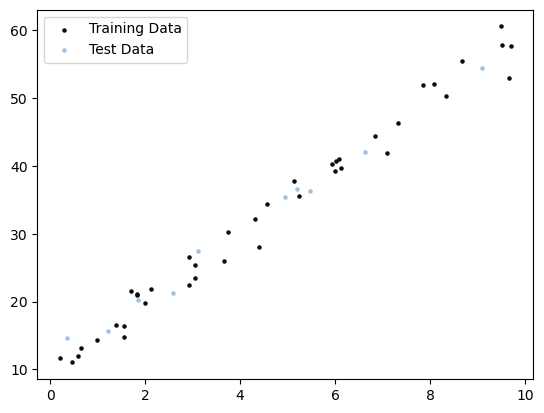

In [9]:
plt.scatter(X_train, y_train, c="#0a0c0e", s=5, label="Training Data")
plt.scatter(X_test, y_test, c="#a0c0e0", s=5, label="Test Data")
plt.legend()
plt.show()

In [10]:
import torch.nn as nn

In [11]:
class LinearRegressionModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1, out_features=1, bias=True)

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)
        
        

In [12]:
torch.manual_seed(42)
model = LinearRegressionModel()
# model = torch.compile(model)

In [13]:
model

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [14]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [15]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(params = model.parameters(), lr=0.01)

In [16]:
epochs = 150
trainingDict = {
    "epoch": [],
    "train_loss": [],
    "test_loss": []
}

for epoch in range(epochs):

    model.train()
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred, y_test)

        if epoch%4==0:
            print(f"Epoch: {epoch:<4} | Train Loss: {loss:.2f} | Test Loss: {test_loss:.2f}")
            trainingDict["epoch"].append(epoch)
            trainingDict["train_loss"].append(loss.item())
            trainingDict["test_loss"].append(test_loss.item())

Epoch: 0    | Train Loss: 965.63 | Test Loss: 160.62
Epoch: 4    | Train Loss: 22.98 | Test Loss: 27.78
Epoch: 8    | Train Loss: 21.54 | Test Loss: 26.38
Epoch: 12   | Train Loss: 20.74 | Test Loss: 25.43
Epoch: 16   | Train Loss: 19.98 | Test Loss: 24.52
Epoch: 20   | Train Loss: 19.25 | Test Loss: 23.65
Epoch: 24   | Train Loss: 18.56 | Test Loss: 22.82
Epoch: 28   | Train Loss: 17.90 | Test Loss: 22.03
Epoch: 32   | Train Loss: 17.26 | Test Loss: 21.26
Epoch: 36   | Train Loss: 16.65 | Test Loss: 20.53
Epoch: 40   | Train Loss: 16.07 | Test Loss: 19.83
Epoch: 44   | Train Loss: 15.52 | Test Loss: 19.15
Epoch: 48   | Train Loss: 14.99 | Test Loss: 18.50
Epoch: 52   | Train Loss: 14.49 | Test Loss: 17.88
Epoch: 56   | Train Loss: 14.00 | Test Loss: 17.29
Epoch: 60   | Train Loss: 13.54 | Test Loss: 16.72
Epoch: 64   | Train Loss: 13.10 | Test Loss: 16.17
Epoch: 68   | Train Loss: 12.68 | Test Loss: 15.64
Epoch: 72   | Train Loss: 12.28 | Test Loss: 15.14
Epoch: 76   | Train Loss: 11.

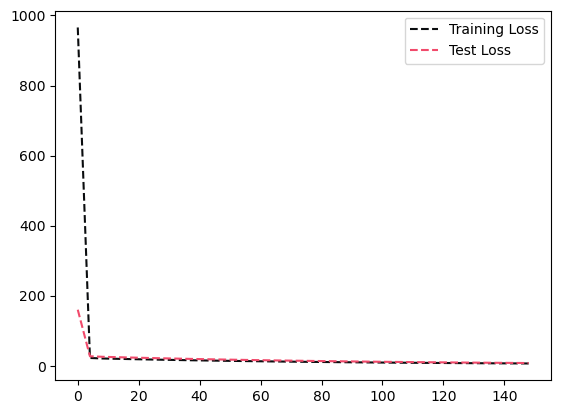

In [17]:
trainingDict
plt.plot(trainingDict["epoch"], trainingDict["train_loss"], c="#0a0c0e", label="Training Loss", linestyle="--")
plt.plot(trainingDict["epoch"], trainingDict["test_loss"], c="#f14a6b", label="Test Loss", linestyle="--")
plt.legend()
plt.show()

In [18]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[5.5556]])),
             ('linear_layer.bias', tensor([6.4143]))])

In [19]:
model.eval()
with torch.inference_mode():
    y_preds = model(X_test)

In [20]:
y_preds

tensor([[13.1942],
        [33.9242],
        [ 8.3248],
        [56.9323],
        [20.7910],
        [43.2212],
        [23.7316],
        [35.3071],
        [36.7872],
        [16.6840]])

In [21]:
y_test

tensor([[15.6626],
        [35.4731],
        [14.6752],
        [54.4295],
        [21.3220],
        [42.1226],
        [27.4164],
        [36.6609],
        [36.2760],
        [20.2693]])

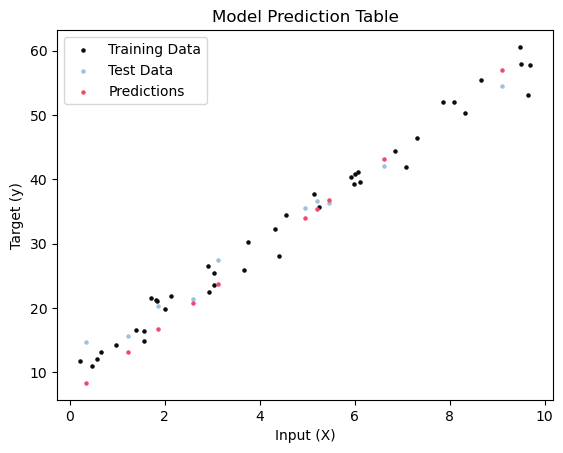

In [22]:
plt.scatter(X_train, y_train, c="#0a0c0e", s=5, label="Training Data")
plt.scatter(X_test, y_test, c="#a0c0e0", s=5, label="Test Data")
plt.scatter(X_test, y_preds, c="#f14a6b", s=5, label="Predictions")
plt.legend()
plt.xlabel("Input (X)")
plt.ylabel("Target (y)")
plt.title("Model Prediction Table")
plt.show()